# Análise Exploratória de Dados - Sample Superstore

Projeto desenvolvido para o desafio extra do curso Introdução ao Data Science - SCTEC.

Autora: Laís Kugik Varela Alegri

**Objetivo:**
Realizar uma análise exploratória dos dados de vendas da empresa Superstore, buscando identificar padrões, tendências e insights relevantes relacionados ao desempenho comercial da empresa.

### 1. Importação dos Dados

#### 1.1 Importação das bibliotecas

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,6)

#### 1.2 Carregamento do dataset

In [211]:
df = pd.read_csv('sample_superstore.csv', encoding='latin-1', dtype={'Postal Code': str})

# dtype={'Postal Code': str} garante que o CEP seja lido como texto — não faz sentido tratá-lo como número

#### 1.3 Exploração inicial dos dados


Nesta etapa foi realizada uma análise inicial da estrutura do dataset para compreender as variáveis disponíveis e verificar possíveis problemas nos dados.

In [212]:
df.head() # retorna os 5 primeiros registros da tabela/dataframe

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [213]:
df.info() # retorna informações gerais da tabela (colunas, nulos e tipo do dado)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   object 
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [214]:
df.describe() # retorna contagem, média, desvio padrão, valor mínimo, P25, P50 (mediana), P75 e valor máximo

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


In [215]:
df.shape # retorna o número total de linhas e de colunas

(9994, 21)

### 2. Tratamento e preparação dos dados

#### 2.1 Verificando valores nulos

In [216]:
df.isnull().sum() # identificando se existem valores nulos nas colunas da tabela

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Foi realizada a verificação de valores nulos na tabela, não existe nenhum.

(OBS: Já era possível identificar essa informação também ao executar df.info() anteriormente.)

#### 2.2 Verificando linhas duplicadas

In [217]:
df.duplicated().sum() # retorna a quantidade de linhas duplicadas

np.int64(0)

Foi realizada a verificação de linhas com valores duplicados na tabela, não existe nenhum.

(OBS: Não será necessário remover com a função `df.drop_duplicates(inplace=True)`)

#### 2.3 Ajustes adicionais  

*   Traduzir para português algumas informações para facilitar o entendimento.
*   Conversão de campos de data.
*   Criação de novas colunas.

In [218]:
# Dicionário de tradução: nome original → nome em português
traducao_colunas = {
    'Row ID'        : 'id_linha',
    'Order ID'      : 'id_pedido',
    'Order Date'    : 'data_pedido',
    'Ship Date'     : 'data_envio',
    'Ship Mode'     : 'modo_envio',
    'Customer ID'   : 'id_cliente',
    'Customer Name' : 'nome_cliente',
    'Segment'       : 'segmento',
    'Country'       : 'pais',
    'City'          : 'cidade',
    'State'         : 'estado',
    'Postal Code'   : 'cep',
    'Region'        : 'regiao',
    'Product ID'    : 'id_produto',
    'Category'      : 'categoria',
    'Sub-Category'  : 'subcategoria',
    'Product Name'  : 'nome_produto',
    'Sales'         : 'vendas',
    'Quantity'      : 'quantidade',
    'Discount'      : 'desconto',
    'Profit'        : 'lucro'
}

df = df.rename(columns=traducao_colunas)

print('\nNovos nomes das colunas:')
print(df.columns.tolist())


Novos nomes das colunas:
['id_linha', 'id_pedido', 'data_pedido', 'data_envio', 'modo_envio', 'id_cliente', 'nome_cliente', 'segmento', 'pais', 'cidade', 'estado', 'cep', 'regiao', 'id_produto', 'categoria', 'subcategoria', 'nome_produto', 'vendas', 'quantidade', 'desconto', 'lucro']


In [219]:
# Conversão de datas
df['data_pedido'] = pd.to_datetime(df['data_pedido'])
df['data_envio']  = pd.to_datetime(df['data_envio'])

# Extração de componentes de data
df['ano']       = df['data_pedido'].dt.year
df['mes']       = df['data_pedido'].dt.month
df['nome_mes']  = df['data_pedido'].dt.strftime('%b')   # Jan, Fev, ...

# Dias de entrega: quanto tempo levou para o cliente receber o pedido?
df['dias_entrega'] = (df['data_envio'] - df['data_pedido']).dt.days

# Margem de lucro por transação (%)
df['margem_lucro'] = np.where(
    df['vendas'] != 0,
    (df['lucro'] / df['vendas'] * 100).round(2),
    0
)

# Tradução das categorias para português
df['categoria'] = df['categoria'].map({
    'Furniture'       : 'Móveis',
    'Office Supplies' : 'Papelaria',
    'Technology'      : 'Tecnologia'
})

# Tradução das subcategorias para português
df['subcategoria'] = df['subcategoria'].map({
    'Bookcases'   : 'Estantes',
    'Chairs'      : 'Cadeiras',
    'Tables'      : 'Mesas',
    'Furnishings' : 'Mobiliário',
    'Appliances'  : 'Eletrodomésticos',
    'Art'         : 'Arte',
    'Binders'     : 'Fichários',
    'Envelopes'   : 'Envelopes',
    'Fasteners'   : 'Grampos',
    'Labels'      : 'Etiquetas',
    'Paper'       : 'Papel',
    'Storage'     : 'Armazenamento',
    'Supplies'    : 'Suprimentos',
    'Accessories' : 'Acessórios',
    'Copiers'     : 'Copiadoras',
    'Machines'    : 'Máquinas',
    'Phones'      : 'Telefones'
})

# Tradução dos segmentos para português
df['segmento'] = df['segmento'].map({
    'Consumer'    : 'Consumidor',
    'Corporate'   : 'Corporativo',
    'Home Office' : 'Home Office'
})

# Tradução das regiões para português
df['regiao'] = df['regiao'].map({
    'West'    : 'Oeste',
    'East'    : 'Leste',
    'Central' : 'Central',
    'South'   : 'Sul'
})

# Tradução dos modos de envio
df['modo_envio'] = df['modo_envio'].map({
    'Standard Class' : 'Padrão',
    'Second Class'   : 'Segunda Classe',
    'First Class'    : 'Primeira Classe',
    'Same Day'       : 'Mesmo Dia'
})

print('Novas colunas criadas: ano, mes, nome_mes, dias_entrega, margem_lucro')
print('Categorias, subcategorias, segmentos e regiões traduzidas!')
print(f'\nFormato final do dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas')

Novas colunas criadas: ano, mes, nome_mes, dias_entrega, margem_lucro
Categorias, subcategorias, segmentos e regiões traduzidas!

Formato final do dataset: 9,994 linhas × 26 colunas


#### 2.4 Identificação de possíveis outliers

Foi realizada a análise de possíveis valores extremos nas variáveis numéricas do dataset, aqui especialmente vou detalhar sobre a variável de vendas.



*   É possível verificar que a maioria das vendas estão na primeira parte do gráfico, até 5.000.
*   De 5.000 a 10.000 já existem bem menos casos.
*   Acima de 10.000 são com certeza os nossos outliers.



Para conseguir identificar melhor, vou calcular o percentil dessa variável.
(abaixo do gráfico)




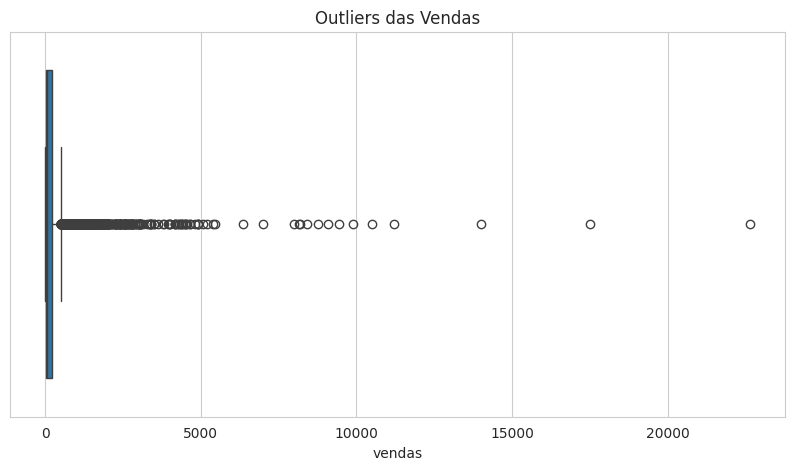

In [220]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['vendas'])

plt.title('Outliers das Vendas')

plt.show()

In [221]:
# Valor do percentil p99
p99_vendas = df['vendas'].quantile(0.99)
print("Valor do percentil P99:", p99_vendas)


# Valor do percentil p95
p95_vendas = df['vendas'].quantile(0.95)
print("Valor do percentil P95:", p95_vendas)

Valor do percentil P99: 2481.694599999993
Valor do percentil P95: 956.9842450000003


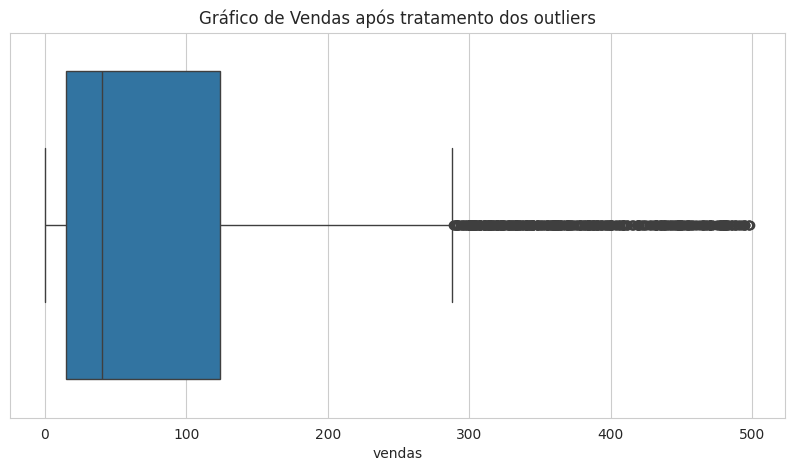


Valor do percentil P25: 17.28
Valor do percentil P75: 209.94
Valor do IQR: 192.66
Limite inferior: -271.71000000000004
Limite superior: 498.93

Quantidade original: 9994
Quantidade sem outliers: 8827


In [222]:
# Tratamento de dados usando IQR - Interquartile Range (ou Intervalo Interquartil)

q1 = df['vendas'].quantile(0.25)
q3 = df['vendas'].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df['vendas'] >= limite_inferior) &
    (df['vendas'] <= limite_superior)
]


# Gráfico sem os outliers de vendas

plt.figure(figsize=(10,5))
sns.boxplot(x=df_sem_outliers['vendas'])
plt.title('Gráfico de Vendas após tratamento dos outliers')
plt.show()

print("\nValor do percentil P25:", q1)
print("Valor do percentil P75:", q3)
print("Valor do IQR:", iqr)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


print("\nQuantidade original:", len(df))
print("Quantidade sem outliers:", len(df_sem_outliers))


In [223]:
print("\nInformações de vendas gerais:")
df['vendas'].describe()


Informações de vendas gerais:


,vendas
count,9994.000000
mean,229.858001
std,623.245101
min,0.444000
25%,17.280000
50%,54.490000
75%,209.940000
max,22638.480000


In [224]:
print("\nInformações de vendas sem outliers:")
df_sem_outliers['vendas'].describe()


Informações de vendas sem outliers:


,vendas
count,8827.000000
mean,92.864853
std,114.045078
min,0.444000
25%,15.008000
50%,40.880000
75%,124.225000
max,498.260000


Com essas informações é possível identificar que a maioria das vendas (95%) foram de valores até 956.98.

A mediana é representada no valor de 54.49.

Os outliers foram identificados, porém mantidos no dataset por representarem vendas reais da empresa.

#### 2.5 Verificando o dataset após alterações

In [225]:
df.head()

,id_linha,id_pedido,data_pedido,data_envio,modo_envio,id_cliente,nome_cliente,segmento,pais,cidade,...,nome_produto,vendas,quantidade,desconto,lucro,ano,mes,nome_mes,dias_entrega,margem_lucro
0,1,CA-2016-152156,2016-11-08,2016-11-11,Segunda Classe,CG-12520,Claire Gute,Consumidor,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Segunda Classe,CG-12520,Claire Gute,Consumidor,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Segunda Classe,DV-13045,Darrin Van Huff,Corporativo,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Padrão,SO-20335,Sean O'Donnell,Consumidor,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Padrão,SO-20335,Sean O'Donnell,Consumidor,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct,7,11.25


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_linha      9994 non-null   int64         
 1   id_pedido     9994 non-null   object        
 2   data_pedido   9994 non-null   datetime64[ns]
 3   data_envio    9994 non-null   datetime64[ns]
 4   modo_envio    9994 non-null   object        
 5   id_cliente    9994 non-null   object        
 6   nome_cliente  9994 non-null   object        
 7   segmento      9994 non-null   object        
 8   pais          9994 non-null   object        
 9   cidade        9994 non-null   object        
 10  estado        9994 non-null   object        
 11  cep           9994 non-null   object        
 12  regiao        9994 non-null   object        
 13  id_produto    9994 non-null   object        
 14  categoria     9994 non-null   object        
 15  subcategoria  9994 non-null   object  

In [227]:
df.describe()

,id_linha,data_pedido,data_envio,vendas,quantidade,desconto,lucro,ano,mes,dias_entrega,margem_lucro
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,3.958175,12.031390
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,0.000000,-275.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,3.000000,7.500000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,4.000000,27.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,5.000000,36.250000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,7.000000,50.000000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,1.747567,46.675436


### 3. Análise Exploratória



#### 3.1 Análise de vendas por subcategoria

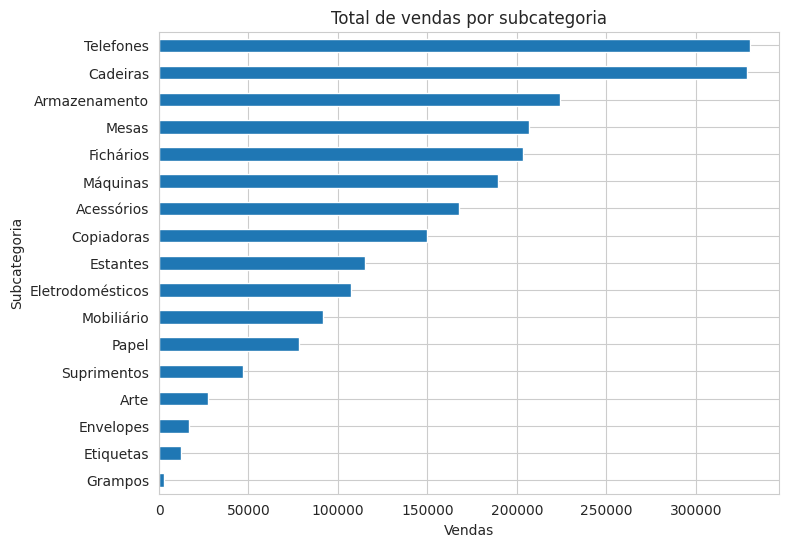

In [228]:
categoria_vendas = df.groupby('subcategoria')['vendas'].sum().sort_values()

categoria_vendas.plot(kind='barh')

plt.title('Total de vendas por subcategoria')
plt.xlabel('Vendas')
plt.ylabel('Subcategoria')

plt.show()

As subcategorias "Telefones", "Cadeiras" e "Armazenamento" representam o maior volume de vendas.

#### 3.2 Análise de lucro por subcategoria

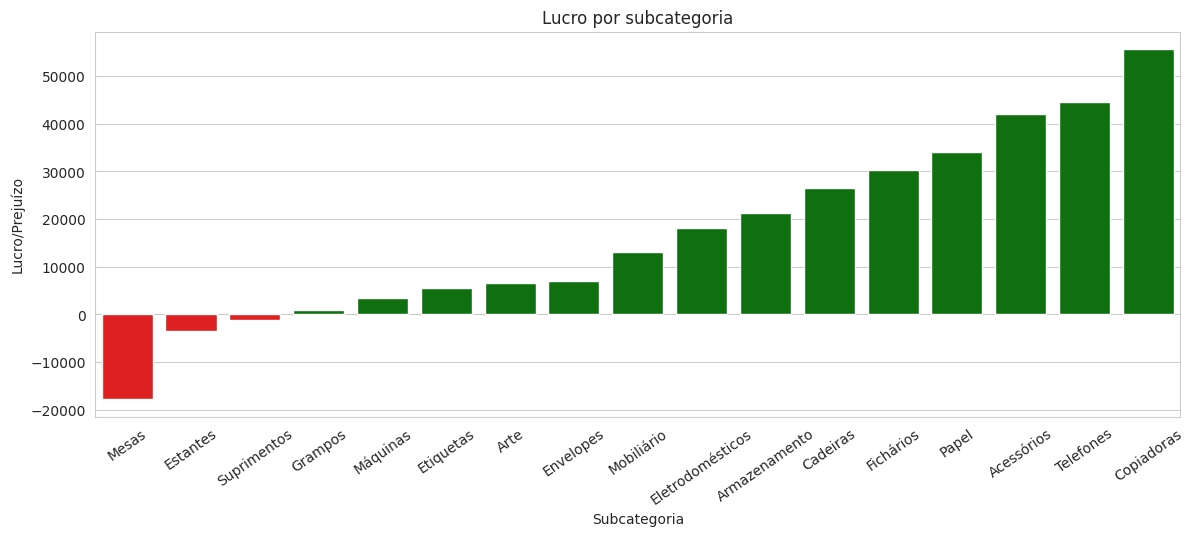

In [234]:
lucro_subcategoria = df.groupby('subcategoria')['lucro'].sum().sort_values()

# deixa valores negativos com a cor vermelha
cores = ['red' if valor < 0 else 'green' for valor in lucro_subcategoria.values]

sns.barplot(
    x=lucro_subcategoria.index,
    y=lucro_subcategoria.values,
    palette=cores,
    hue=lucro_subcategoria.index
)

plt.title('Lucro por subcategoria')
plt.xlabel('Subcategoria')
plt.ylabel('Lucro/Prejuízo')
plt.rcParams['figure.figsize'] = (15,5) # tamanho (horizozntal,vertical)
plt.xticks(rotation=35)

plt.show()

Apesar do alto volume de vendas, algumas subcategorias apresentaram prejuízo, como: "Mesas", "Estantes" e "Suprimentos". Indicando possíveis impactos de descontos e custos operacionais.

#### 3.3 Análise de desconto X lucro

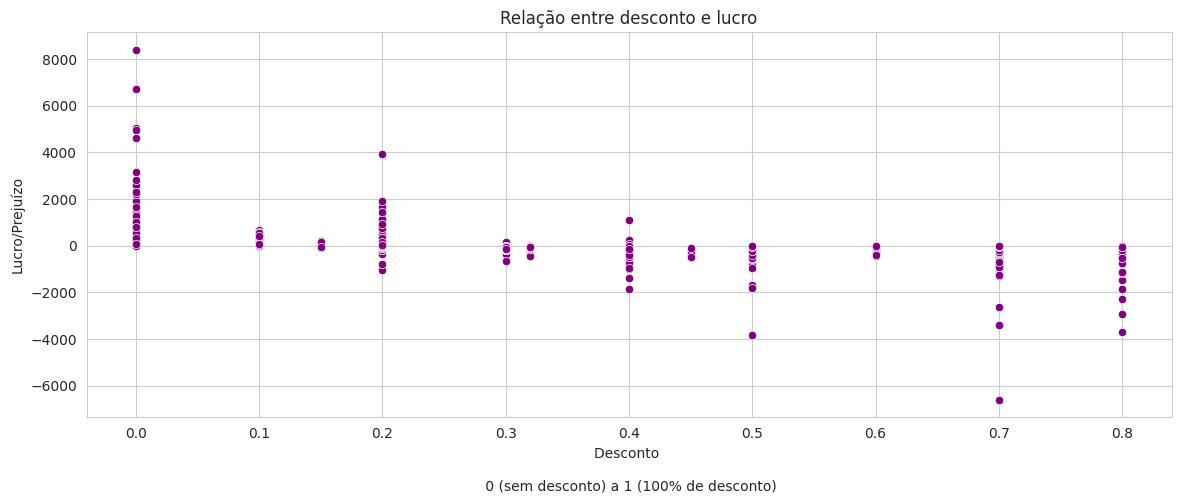

In [230]:
sns.scatterplot(
    data=df,
    x='desconto',
    y='lucro',
    color='purple'
)

plt.title('Relação entre desconto e lucro')
plt.xlabel('Desconto \n\n 0 (sem desconto) a 1 (100% de desconto)')
plt.ylabel('Lucro/Prejuízo')
plt.rcParams['figure.figsize'] = (15,6)
plt.show()

Foi possível observar que descontos mais elevados tendem a reduzir significativamente o lucro, podendo gerar prejuízo em determinadas vendas.

#### 3.4 Análise vendas por segmento de clientes

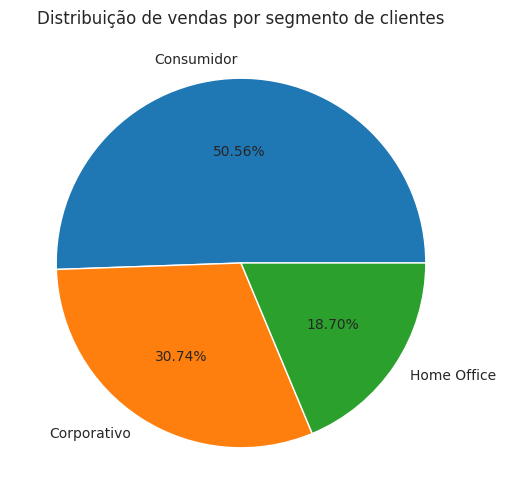

In [231]:
segmento = df.groupby('segmento')['vendas'].sum()

segmento.plot(kind='pie', autopct='%1.2f%%')

plt.title('Distribuição de vendas por segmento de clientes')

plt.ylabel('')

plt.show()

O segmento "Consumidor" representa a maior parcela das vendas realizadas pela empresa.

#### 3.5 Análise da evolução temporal das vendas

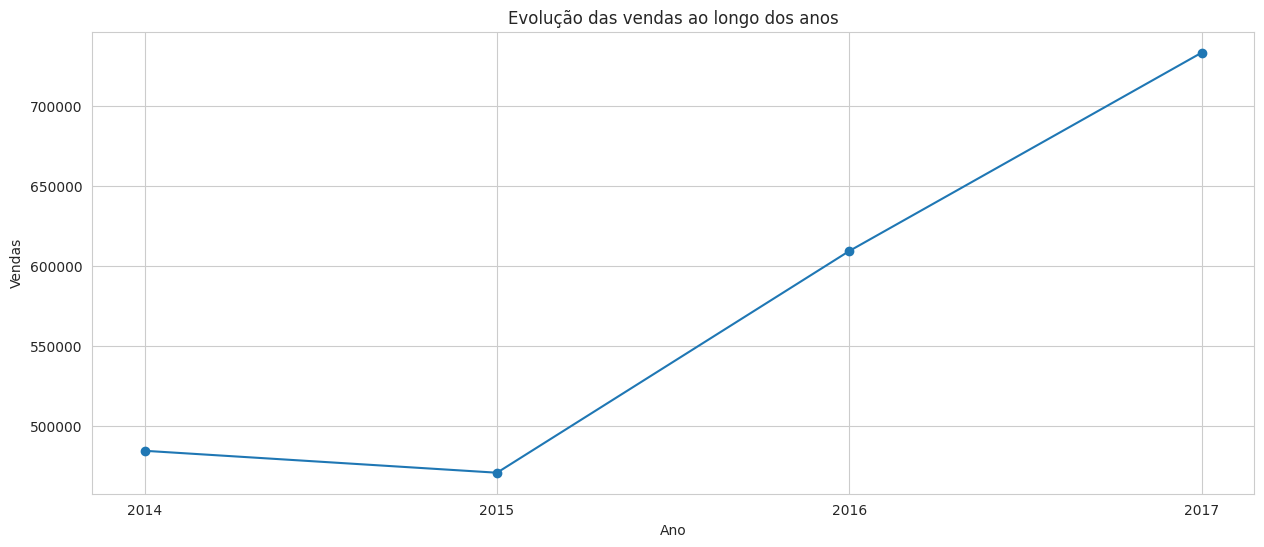

In [232]:
vendas_ano = df.groupby('ano')['vendas'].sum()

plt.plot(vendas_ano.index, vendas_ano.values, marker='o')

plt.title('Evolução das vendas ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Vendas')
plt.xticks([2014, 2015, 2016, 2017])

plt.show()

É possível observar que do ano de 2014 até 2015 houve uma redução nas vendas. A partir de 2015 as vendas cresceram significativamente no período analisado (até 2017).

#### 3.6 Top 10 produtos mais vendidos

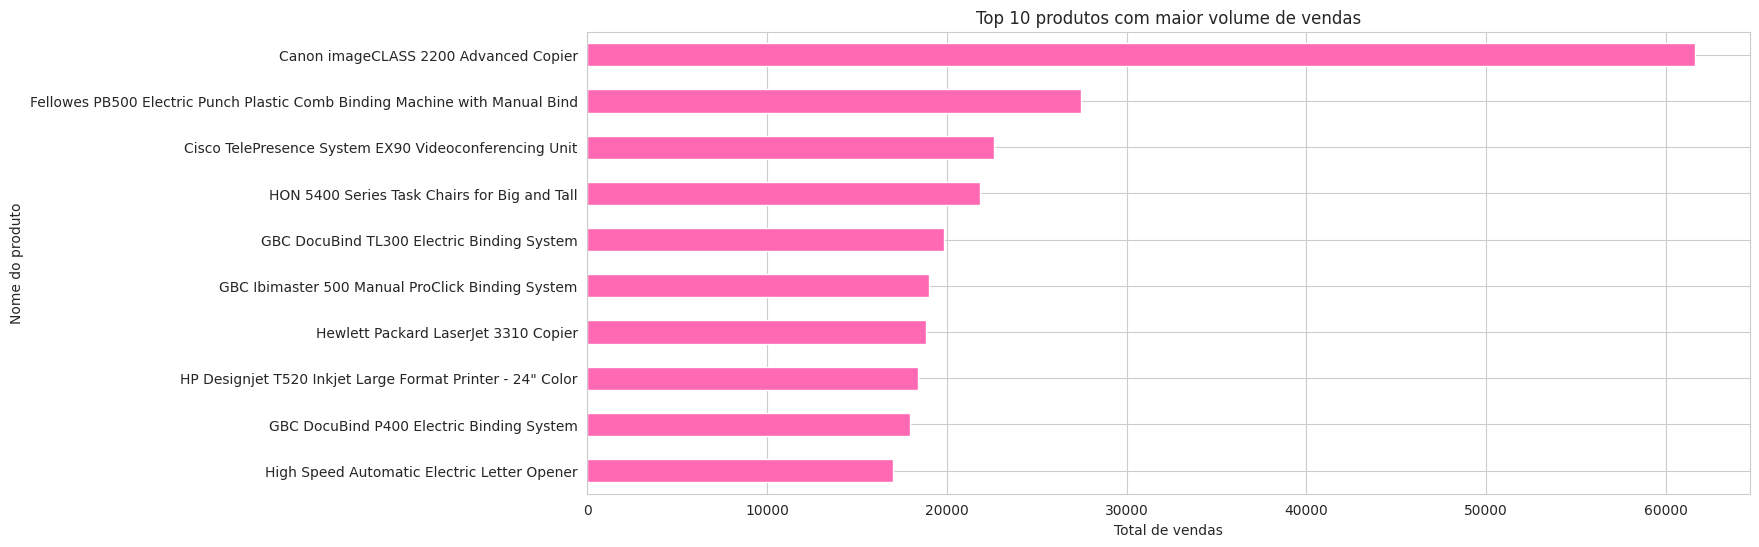

In [233]:
top_produtos = (
    df.groupby('nome_produto')['vendas']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_produtos.plot(kind='barh', color='hotpink')

plt.rcParams['figure.figsize'] = (14,5)
plt.gca().invert_yaxis()

plt.title('Top 10 produtos com maior volume de vendas')

plt.ylabel('Nome do produto')
plt.xlabel('Total de vendas')
plt.show()

# Conclusão

A análise exploratória permitiu identificar padrões relevantes relacionados ao desempenho comercial da empresa.

Os resultados mostraram que a subcategoria "Telefones" possui destaque tanto em vendas quanto em lucratividade. Também foi identificado que descontos elevados impactam negativamente o lucro em diversas situações, como é o exemplo da subcategoria "Mesas" que apesar de estar em 4º lugar nas vendas, é a que possui menos lucratividade, e está gerando prejuízos por causa dos descontos aplicados.

Além disso, o segmento de clientes "Consumidor" apresentou maior participação nas vendas totais da empresa.

De modo geral, a análise contribui para compreender melhor o comportamento das vendas e lucros por segmento, e apoiar futuras tomadas de decisão baseadas em dados.

In [237]:
# Exportando arquivo otimizado para criar a visualização no Looker Studio

# Seleciona as colunas para o dashboard
colunas_dashboard = [
    'id_pedido', 'data_pedido', 'ano', 'mes', 'nome_mes',
    'segmento', 'regiao', 'estado', 'cidade',
    'categoria', 'subcategoria', 'nome_produto',
    'modo_envio', 'dias_entrega',
    'vendas', 'quantidade', 'desconto', 'lucro', 'margem_lucro'
]

df_dashboard = df[colunas_dashboard].copy()

# Salva o arquivo CSV
df_dashboard.to_csv('superstore_dashboard.csv', index=False)

print(f'✅ Arquivo exportado: superstore_dashboard.csv')

✅ Arquivo exportado: superstore_dashboard.csv


In [ ]:
# Converte a coluna "data_pedido" para o formato de data no Looker Studio
# PARSE_DATE("%Y-%m-%d", data_pedido)